In [12]:
#1環境確認
import torch
import monai
print("PyTorch version:", torch.__version__)
print("MONAI version:", monai.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.6.0+cu118
MONAI version: 1.4.0
CUDA available: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [14]:
# Import 和 Config
import os, random
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

from monai.utils import set_determinism
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd,
    NormalizeIntensityd, Lambdad, EnsureTyped, EnsureType,
    AsDiscrete, RandCropByPosNegLabeld, DivisiblePadd,
    RandAffined, RandFlipd
)
from monai.data import Dataset, DataLoader, decollate_batch
from monai.networks.nets import UNet
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric
from monai.inferers import sliding_window_inference
from torch.optim.lr_scheduler import ReduceLROnPlateau

# ── 放入圖片的路徑 ──────────────────────────────
DATA_ROOT = r"D:\data mining datasets\Task01_BrainTumour\Task01_BrainTumour"
# ─────────────────────────────────────────────

IMG_DIR = Path(DATA_ROOT) / "imagesTr"
LBL_DIR = Path(DATA_ROOT) / "labelsTr"

MAX_EPOCHS    = 120
VAL_EVERY     = 5
ROI_SIZE      = (128, 128, 128)
SW_BS         = 4
LR            = 2e-4
WEIGHT_DECAY  = 1e-5
BATCH_SIZE    = 1
NUM_WORKERS   = 0
SEED          = 42

set_determinism(SEED)
torch.backends.cudnn.benchmark = False
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [16]:
#3 資料切分 + Transforms
# ── 資料配對 ──────────────────────────────────
all_images = sorted(IMG_DIR.glob("BRATS_*.nii.gz"))
pairs = []
for img in all_images:
    lab = LBL_DIR / img.name
    if lab.exists():
        pairs.append({"image": str(img), "label": str(lab)})

assert len(pairs) >= 10, f"Need >=10 cases, got {len(pairs)}"
rnd = random.Random(SEED)
rnd.shuffle(pairs)
split = max(1, int(len(pairs) * 0.8))
train_files, val_files = pairs[:split], pairs[split:]
print(f"Train: {len(train_files)} | Val: {len(val_files)}")

# ── Transforms ────────────────────────────────
common_load = [
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    # ✅ 修正：用 NormalizeIntensity + channel_wise，對每個 MRI modality 分開 Z-score
    NormalizeIntensityd(keys=["image"], nonzero=True, channel_wise=True),
    # ✅ Binary label：把 0/1/2/3 → 0/1
    Lambdad(keys="label", func=lambda x: (x > 0).astype(np.uint8)),
]

train_transforms = Compose(
    common_load + [
        RandCropByPosNegLabeld(
            keys=["image", "label"], label_key="label",
            spatial_size=(96, 96, 96), pos=4, neg=1, num_samples=4
        ),
        # 輕量幾何增強
        RandAffined(
            keys=["image", "label"], prob=0.3,
            rotate_range=(np.deg2rad(10),)*3,
            scale_range=(0.1, 0.1, 0.1),
            translate_range=(5, 5, 5),
            mode=("bilinear", "nearest"),
            padding_mode="border"
        ),
        RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=0),
        EnsureTyped(keys=["image", "label"]),
    ]
)

val_transforms = Compose(
    common_load + [
        DivisiblePadd(keys=["image", "label"], k=16),
        EnsureTyped(keys=["image", "label"]),
    ]
)

# ── DataLoader ────────────────────────────────
train_ds = Dataset(train_files, transform=train_transforms)
val_ds   = Dataset(val_files,   transform=val_transforms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_ds,   batch_size=1,          shuffle=False, num_workers=NUM_WORKERS)
print("DataLoader ready ✅")

Train: 387 | Val: 97
DataLoader ready ✅


In [20]:
# 4 Model / Loss / Optimizer
model = UNet(
    spatial_dims=3,
    in_channels=4,
    out_channels=1,
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    num_res_units=2,
).to(device)

criterion = DiceCELoss(
    sigmoid=True, to_onehot_y=False, include_background=False,
    squared_pred=True, smooth_nr=1e-5, smooth_dr=1e-5
)

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=6)

dice_metric = DiceMetric(include_background=False, reduction="mean", get_not_nans=False)
post_pred  = Compose([EnsureType(), AsDiscrete(threshold=0.5)])
post_label = Compose([EnsureType()])

print("Model ready ✅  Params:", sum(p.numel() for p in model.parameters()) // 1_000_000, "M")

Model ready ✅  Params: 4 M


In [26]:
#5 - Training Loop
train_losses, val_dices = [], []
best_dice, best_epoch = 0.0, -1

for ep in range(1, MAX_EPOCHS + 1):
    # ── Train ──────────────────────────────────
    model.train()
    epoch_loss, steps = 0.0, 0
    for batch in train_loader:
        img = batch["image"].to(device)
        lab = batch["label"].float().to(device)
        optimizer.zero_grad()
        logits = model(img)
        loss = criterion(logits, lab)
        loss.backward()
        # ✅ Gradient clipping：防止梯度爆炸
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()
        steps += 1
    epoch_loss /= max(1, steps)
    train_losses.append(epoch_loss)

    # ── Validation（每 VAL_EVERY epochs）──────
    if ep % VAL_EVERY == 0:
        model.eval()
        dice_metric.reset()
        with torch.no_grad():
            for batch in val_loader:   # ✅ 修正：跑完整 val set，不是單一 case
                img = batch["image"].to(device)
                lab = batch["label"].float().to(device)
                logits = sliding_window_inference(
                    img, roi_size=ROI_SIZE, sw_batch_size=SW_BS,
                    predictor=model, overlap=0.5
                )
                prob = torch.sigmoid(logits)
                preds = [post_pred(x) for x in decollate_batch(prob)]
                gts   = [post_label(x) for x in decollate_batch(lab)]
                dice_metric(y_pred=preds, y=gts)

        mean_dice = float(dice_metric.aggregate().item())
        val_dices.append(mean_dice)
        scheduler.step(mean_dice)

        if mean_dice > best_dice:
            best_dice, best_epoch = mean_dice, ep
            torch.save({"epoch": ep, "model": model.state_dict(), "dice": mean_dice}, "best_binary.pth")
            print(f"  ★ New best saved!")

        print(f"Epoch {ep:03d}/{MAX_EPOCHS} | LR {optimizer.param_groups[0]['lr']:.2e} "
              f"| TrainLoss {epoch_loss:.4f} | ValDice {mean_dice:.4f}")
    else:
        print(f"Epoch {ep:03d}/{MAX_EPOCHS} | TrainLoss {epoch_loss:.4f}")

print(f"\n✅ Best ValDice: {best_dice:.4f} @ epoch {best_epoch}")

Epoch 001/120 | TrainLoss 1.1050
Epoch 002/120 | TrainLoss 0.9647
Epoch 003/120 | TrainLoss 0.8376
Epoch 004/120 | TrainLoss 0.7070
  ★ New best saved!
Epoch 005/120 | LR 2.00e-04 | TrainLoss 0.6136 | ValDice 0.7926
Epoch 006/120 | TrainLoss 0.5583
Epoch 007/120 | TrainLoss 0.4920
Epoch 008/120 | TrainLoss 0.4637
Epoch 009/120 | TrainLoss 0.4230
Epoch 010/120 | LR 2.00e-04 | TrainLoss 0.4134 | ValDice 0.7336
Epoch 011/120 | TrainLoss 0.3746
Epoch 012/120 | TrainLoss 0.3797
Epoch 013/120 | TrainLoss 0.3417
Epoch 014/120 | TrainLoss 0.3085
  ★ New best saved!
Epoch 015/120 | LR 2.00e-04 | TrainLoss 0.2793 | ValDice 0.8927
Epoch 016/120 | TrainLoss 0.2623
Epoch 017/120 | TrainLoss 0.2417
Epoch 018/120 | TrainLoss 0.2332
Epoch 019/120 | TrainLoss 0.2254
Epoch 020/120 | LR 2.00e-04 | TrainLoss 0.2279 | ValDice 0.8876
Epoch 021/120 | TrainLoss 0.2277
Epoch 022/120 | TrainLoss 0.2176
Epoch 023/120 | TrainLoss 0.2080
Epoch 024/120 | TrainLoss 0.2150
  ★ New best saved!
Epoch 025/120 | LR 2.00e

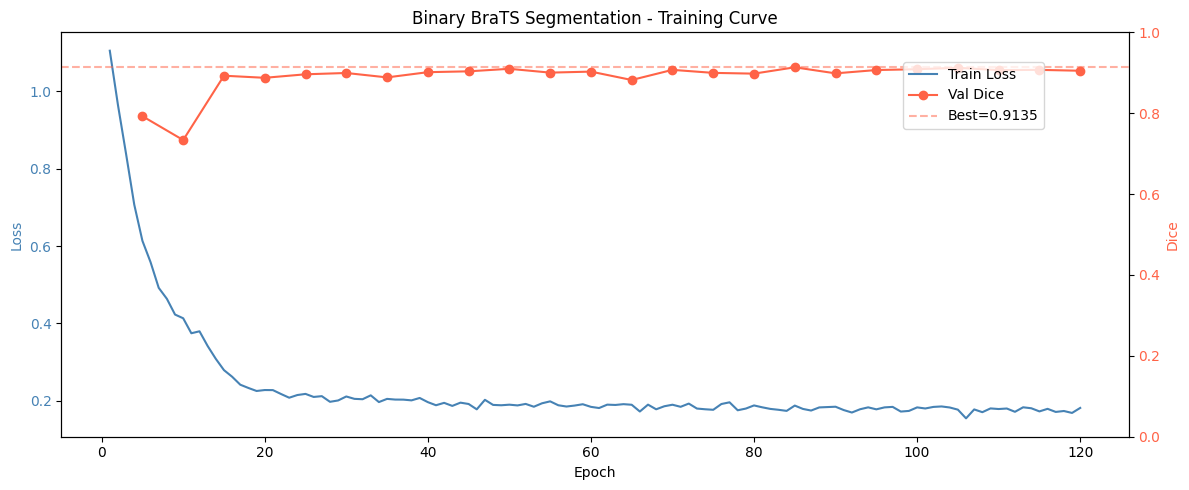

Best ValDice: 0.9135 @ epoch 85


In [28]:
# Cell 6 - 畫圖
val_epochs = list(range(VAL_EVERY, MAX_EPOCHS + 1, VAL_EVERY))

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(range(1, MAX_EPOCHS + 1), train_losses, color="steelblue", label="Train Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")

ax2 = ax1.twinx()
ax2.plot(val_epochs, val_dices, color="tomato", marker="o", label="Val Dice")
ax2.set_ylabel("Dice", color="tomato")
ax2.tick_params(axis="y", labelcolor="tomato")
ax2.set_ylim(0, 1)
ax2.axhline(y=best_dice, color="tomato", linestyle="--", alpha=0.5, label=f"Best={best_dice:.4f}")

fig.legend(loc="upper right", bbox_to_anchor=(0.88, 0.88))
plt.title("Binary BraTS Segmentation - Training Curve")
plt.tight_layout()
plt.savefig("training_curve.png", dpi=150)
plt.show()
print(f"Best ValDice: {best_dice:.4f} @ epoch {best_epoch}")